In [84]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns


In [90]:
cleaned_train = pd.read_csv('../data/train/cleaned_train.csv')


# Versionado

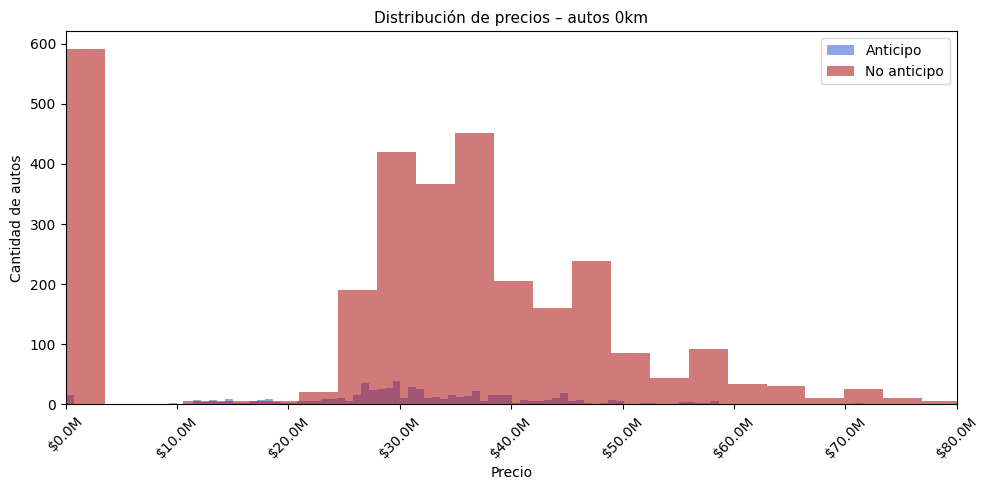

In [93]:
# Filter for new cars (less than 1000 km)
new_cars = cleaned_train[cleaned_train['Kilómetros'] < 500]

# Create masks for anticipo and no anticipo
mask_anticipo = new_cars['price_is_anticipo'] == 1
mask_no_anticipo = new_cars['price_is_anticipo'] == 0

cheap_cars = new_cars[new_cars['Precio'] < 10_000_000]
cheap_cars.to_csv('../data/outliers.csv')

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 5))

# Plot overlapping histograms
ax.hist(new_cars.loc[mask_anticipo, 'Precio'], bins=100, 
        color="royalblue", alpha=0.6, label="Anticipo")
ax.hist(new_cars.loc[mask_no_anticipo, 'Precio'], bins=100,
        color="firebrick", alpha=0.6, label="No anticipo")

# Set x-axis limits
ax.set_xlim(0, 8e7)

# Customize plot
ax.set_title("Distribución de precios – autos 0km", fontsize=11)
ax.set_xlabel("Precio")
ax.set_ylabel("Cantidad de autos")
ax.legend()

# Format x-axis with millions
fmt_pesos = plt.FuncFormatter(lambda x, pos: f"${x/1_000_000:.1f}M")
ax.xaxis.set_major_formatter(fmt_pesos)
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

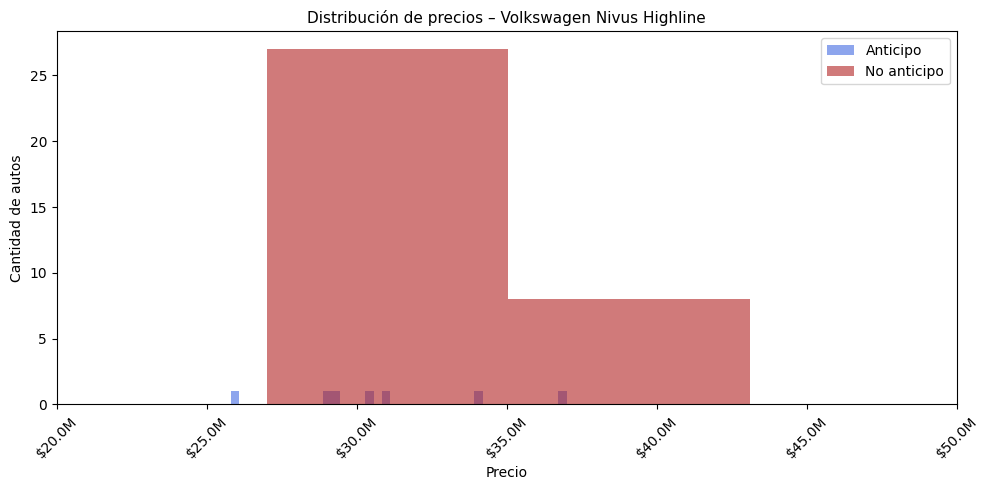

In [87]:
# Select a specific brand/model/version to analyze
brand = "Volkswagen"
model = "Nivus"
version = "Highline"

# Create mask for selection
base_mask = (
    (cleaned_train["Marca"] == brand) & \
    (cleaned_train["Modelo"] == model) & \
    (cleaned_train["Versión"] == version) & \
    (cleaned_train["Kilómetros"] < 1000)
)

mask_anticipo = base_mask & (cleaned_train['price_is_anticipo'] == 1)
mask_no_anticipo = base_mask & (cleaned_train['price_is_anticipo'] == 0)

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 5))

# Plot overlapping histograms
ax.hist(cleaned_train.loc[mask_anticipo, 'Precio'], bins=40, 
        color="royalblue", alpha=0.6, label="Anticipo")
ax.hist(cleaned_train.loc[mask_no_anticipo, 'Precio'], bins=40,
        color="firebrick", alpha=0.6, label="No anticipo")

ax.set_xlim(2e7, 5e7)

# Customize plot
ax.set_title(f"Distribución de precios – {brand} {model} {version}", fontsize=11)
ax.set_xlabel("Precio")
ax.set_ylabel("Cantidad de autos")
ax.legend()

# Format x-axis with millions
fmt_pesos = plt.FuncFormatter(lambda x, pos: f"${x/1_000_000:.1f}M")
ax.xaxis.set_major_formatter(fmt_pesos)
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()
